# Train YOLO on HAGRID 'ok' Gesture Dataset

This notebook trains a YOLO model to detect the 'ok' hand gesture.

In [1]:
# Cell 1: Install and Import
import subprocess
import sys

print("Installing ultralytics...")
subprocess.check_call([sys.executable, "-m", "pip", "install", "ultralytics", "-q"])

from ultralytics import YOLO
import torch

print(f"\n✅ PyTorch: {torch.__version__}")
print(f"✅ CUDA Available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"✅ GPU: {torch.cuda.get_device_name(0)}")
else:
    print("⚠️  Using CPU (slower)")

Installing ultralytics...

✅ PyTorch: 2.9.1+cpu
✅ CUDA Available: False
⚠️  Using CPU (slower)


In [2]:
# Cell 2: Prepare Dataset from Raw Data
import os
import shutil
import random
import json
from pathlib import Path

print('\n📊 Preparing dataset from raw data...')
print('='*50)

# Set random seed for reproducibility
random.seed(42)

# Paths
raw_no_gesture_dir = Path('data/raw/hagrid_30k/no_gesture')
raw_ok_dir = Path('data/raw/hagrid_30k/ok')
annotations_file = Path('data/raw/ann_train_val/ok.json')
output_dir = Path('data/processed_from_raw')

# Load annotations
print('\n1️⃣ Loading annotations...')
with open(annotations_file, 'r') as f:
    annotations = json.load(f)
print(f'   Loaded {len(annotations)} annotation entries')

# Get list of actual ok images that exist
existing_ok_images = set(p.stem for p in raw_ok_dir.glob('*.jpg'))
print(f'   Found {len(existing_ok_images)} actual ok images')

# Filter annotations to only existing images
valid_annotations = {k: v for k, v in annotations.items() if k in existing_ok_images}
print(f'   Valid annotations: {len(valid_annotations)}')

# Split 80/20 train/val
print('\n2️⃣ Splitting data 80/20 train/val...')
ok_image_ids = list(valid_annotations.keys())

# Use all available ok images (no sampling limit - maximizing training data)
# ok_image_ids = random.sample(ok_image_ids, min(1000, len(ok_image_ids)))
random.shuffle(ok_image_ids)
train_size = int(len(ok_image_ids) * 0.8)
train_ok_ids = ok_image_ids[:train_size]
val_ok_ids = ok_image_ids[train_size:]
print(f'   Train: {len(train_ok_ids)} ok images')
print(f'   Val: {len(val_ok_ids)} ok images')

# NOTE: No-gesture class removed - using 'ok' gesture images only
# (No-gesture sampling code removed)
train_no_gesture = []
val_no_gesture = []



📊 Preparing dataset from raw data...

1️⃣ Loading annotations...
   Loaded 27999 annotation entries
   Found 1750 actual ok images
   Valid annotations: 1750

2️⃣ Splitting data 80/20 train/val...
   Train: 1400 ok images
   Val: 350 ok images



📸 Loading sample image with annotation...
   Image: 39cbe112-fc3e-4a42-bd25-c0f14ca4bcf9.jpg
   Size: 513x384
   Annotations: 1 ok gesture(s)


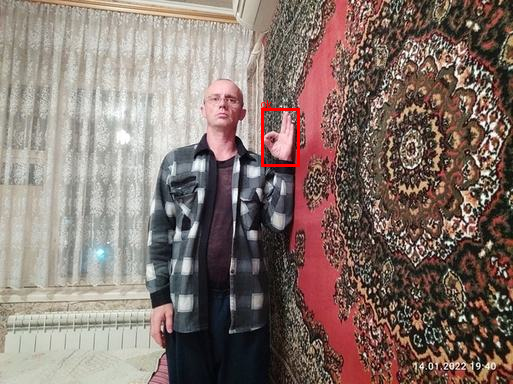

In [13]:
# Display a sample image with annotation
print("\n📸 Loading sample image with annotation...")
import json
import random
from PIL import Image, ImageDraw
from pathlib import Path

# Load annotations
with open('data/raw/ann_train_val/ok.json', 'r') as f:
    annotations = json.load(f)

# Pick a random image with ok annotation
ok_dir = Path('data/raw/hagrid_30k/ok')
ok_images = list(ok_dir.glob('*.jpg'))
sample_img = random.choice(ok_images)
img_id = sample_img.stem

# Load image
img = Image.open(sample_img)
img_width, img_height = img.size

# Get annotations for this image
if img_id in annotations:
    ann = annotations[img_id]
    draw = ImageDraw.Draw(img)
    
    # Draw bounding boxes
    for bbox, label in zip(ann['bboxes'], ann['labels']):
        if label == 'ok':
            # Convert normalized coords to pixel coords
            # HaGRID uses COCO format: [x_min, y_min, width, height]
            x_min, y_min, width, height = bbox
            x1 = int(x_min * img_width)
            y1 = int(y_min * img_height)
            x2 = int((x_min + width) * img_width)
            y2 = int((y_min + height) * img_height)
            # Draw rectangle
            draw.rectangle([x1, y1, x2, y2], outline='red', width=3)
            draw.text((x1, y1-10), 'ok', fill='red')
    
    print(f"   Image: {sample_img.name}")
    print(f"   Size: {img_width}x{img_height}")
    print(f"   Annotations: {len([l for l in ann['labels'] if l == 'ok'])} ok gesture(s)")
    display(img)
else:
    print(f"   No annotation found for {sample_img.name}")

print("\n" + "="*50 + "\n")

In [14]:
# Create output directories
print('\n4️⃣ Creating output directories...')
for split in ['train', 'val']:
    (output_dir / 'images' / split).mkdir(parents=True, exist_ok=True)
    (output_dir / 'labels' / split).mkdir(parents=True, exist_ok=True)

# Function to convert bboxes to YOLO format labels
def create_yolo_labels(image_id, annotation, label_dir):
    """Create YOLO format label file for ok bboxes only"""
    bboxes = annotation['bboxes']
    labels = annotation['labels']
    
    # Filter for ok labels only (class 0)
    ok_lines = []
    for bbox, label in zip(bboxes, labels):
        if label == 'ok':
            # HaGRID uses COCO format: [x_min, y_min, width, height]
            x_min, y_min, width, height = bbox
            # Convert COCO [x_min, y_min, width, height] to YOLO [x_center, y_center, width, height]
            x_center = x_min + width / 2
            y_center = y_min + height / 2
            # Output in standard YOLO format: class x_center y_center width height
            ok_lines.append(f"0 {x_center:.6f} {y_center:.6f} {width:.6f} {height:.6f}\n")
    
    # Write label file
    label_path = label_dir / f"{image_id}.txt"
    if ok_lines:
        with open(label_path, 'w') as f:
            f.writelines(ok_lines)
    else:
        # No ok bboxes - create empty file (background)
        label_path.touch()

def copy_ok_images_with_labels(ok_ids, annotations, split):
    """Copy ok images and create their labels"""
    img_dir = output_dir / 'images' / split
    label_dir = output_dir / 'labels' / split
    copied = 0
    
    for image_id in ok_ids:
        # Copy image
        src_img = raw_ok_dir / f"{image_id}.jpg"
        dst_img = img_dir / f"{image_id}.jpg"
        if src_img.exists():
            shutil.copy2(src_img, dst_img)
            # Create label file
            create_yolo_labels(image_id, annotations[image_id], label_dir)
            copied += 1
    
    return copied

# Copy ok images with labels
print('\n5️⃣ Copying ok images and generating labels...')
ok_train_copied = copy_ok_images_with_labels(train_ok_ids, valid_annotations, 'train')
ok_val_copied = copy_ok_images_with_labels(val_ok_ids, valid_annotations, 'val')
print(f'   Train: {ok_train_copied} images')
print(f'   Val: {ok_val_copied} images')

# NOTE: No-gesture samples not copied (class removed)
no_train_copied = 0
no_val_copied = 0



4️⃣ Creating output directories...

5️⃣ Copying ok images and generating labels...
   Train: 1400 images
   Val: 350 images

6️⃣ Copying no-gesture samples...
   Train: 4000 images
   Val: 1000 images


In [ ]:
# Create dataset.yaml
print('\n7️⃣ Creating dataset.yaml...')
yaml_path = output_dir / 'dataset.yaml'
yaml_content = f"""path: {output_dir.absolute()}
train: images/train
val: images/val
nc: 1
names: ['ok']
"""
with open(yaml_path, 'w') as f:
    f.write(yaml_content)

# Print summary
print('\n' + '='*50)
print('✅ Dataset preparation complete!')
print('='*50)
total_train = ok_train_copied
total_val = ok_val_copied
print(f"Train: {ok_train_copied} ok images")
print(f"Val: {ok_val_copied} ok images")
print(f"\nDataset config: {yaml_path}")
print("\nClass mapping:")
print("  Class 0: ok (single class - no-gesture removed)")


In [ ]:
# Cell: Load Model
print("\nLoading YOLO model...")

# Choose model size: n (nano), s (small), m (medium)
model = YOLO('yolo11n.pt')  # Start with nano for faster training

print(f"✅ Model loaded: yolo11n")
print(f"   Task: {model.task}")
print(f"   Classes: {model.names}")

In [ ]:
# Cell: Train
print("\nStarting training...")
print("This will take 15-30 minutes on CPU, or 5-10 minutes on GPU\n")

# Training configuration
results = model.train(
    data='data/processed_from_raw/dataset.yaml',  # Dataset config
    epochs=10,                           # Training iterations
    imgsz=640,                           # Image size
    batch=16,                            # Batch size (reduce to 8 if OOM)
    device='cpu',                        # Use '0' for GPU, 'cpu' for CPU
    patience=10,                         # Early stopping patience
    save=True,                           # Save best model
    project='runs/detect',               # Output directory
    name='train',                        # Run name
    exist_ok=True,                       # Overwrite if exists
    # Augmentation for rotation/flip robustness
    degrees=25.0,                        # Random rotation up to ±25 degrees
    flipud=0.5,                          # 50% vertical flip probability
    fliplr=0.5,                          # 50% horizontal flip probability
    shear=10.0,                          # Shear transformation up to ±10 degrees
    perspective=0.001,                   # Slight perspective distortion
    mixup=0.1,                           # Mixup augmentation
    copy_paste=0.1                       # Copy-paste augmentation
)

print("\n✅ Training complete!")

In [ ]:
# Cell: View Results
from pathlib import Path
from IPython.display import Image as IPImage, display

print("\nTraining Results:")
print("="*50)

# Get training directory
train_dir = Path('runs/detect/train')

if train_dir.exists():
    print(f"\n📁 Results saved to: {train_dir.resolve()}")
    
    # List files
    weights_dir = train_dir / 'weights'
    if weights_dir.exists():
        print(f"\n💾 Model weights:")
        for w in weights_dir.glob('*.pt'):
            size_mb = w.stat().st_size / (1024*1024)
            print(f"   - {w.name} ({size_mb:.1f} MB)")
    
    # Show results image if exists
    results_img = train_dir / 'results.png'
    if results_img.exists():
        print(f"\n📊 Results plot: {results_img}")
        display(IPImage(filename=str(results_img)))
else:
    print("❌ Training directory not found")

In [ ]:
# Cell: Test Inference
print("\nTesting trained model...")

# Load best model
best_model = YOLO('runs/detect/train/weights/best.pt')

# Test on validation image
import random
from pathlib import Path

val_images = list(Path('data/processed_from_raw/images/val').glob('*.jpg'))
if val_images:
    test_img = random.choice(val_images)
    print(f"\n🖼️  Testing on: {test_img.name}")
    
    # Run inference
    results = best_model(test_img)
    
    # Display results
    results[0].show()
    
    # Print detections
    boxes = results[0].boxes
    if boxes:
        print(f"\n✅ Detected {len(boxes)} 'ok' gesture(s)")
        for i, box in enumerate(boxes):
            conf = float(box.conf)
            print(f"   Detection {i+1}: confidence={conf:.2%}")
    else:
        print(f"\n⚠️  No 'ok' gesture detected in this image")
else:
    print("❌ No validation images found")

In [ ]:
# Cell: Export Model (Optional)
print("\nExporting model...")

# Export to ONNX format (for deployment)
best_model = YOLO('runs/detect/train/weights/best.pt')
best_model.export(format='onnx')

print("\n✅ Model exported to ONNX format")
print("   Location: runs/detect/train/weights/best.onnx")